# Laptop Price Prediction: Preprocessing, Feature Engineering, and Regression Modeling

This notebook outlines a comprehensive end-to-end Machine Learning pipeline to predict laptop prices based on their hardware specifications.

## Key Objectives:
1. **Data Cleaning & Advanced Feature Engineering:** Extracting structured numerical and categorical values from raw hardware description strings (RAM, Storage, CPU, GPU).
2. **Mitigating Data Leakage:** Implementing scikit-learn pipelines to ensure that all preprocessing steps (scaling, encoding, imputation) are fit only on the training split.
3. **Handling Target Imbalance/Skewness:** Applying log-transformation to the highly right-skewed target variable (`price`) to improve regression accuracy.
4. **Baseline Model Comparison:** Training and evaluating a diverse list of regressors (Linear Regression, Regularized models, Trees, and Ensembles).
5. **Overfitting/Underfitting Diagnostics:** Systematically analyzing training vs. testing errors to identify bias/variance issues.
6. **Hyperparameter Tuning:** Fine-tuning the best model using both **Grid Search** and **Randomized Search** cross-validation.

## Step 1: Libraries & Imports
We begin by importing the necessary libraries for data manipulation, visualization, preprocessing, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Leakage Prevention
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## Step 2: Load the Dataset
We load the laptop dataset from the local `data.csv` file.

In [2]:
import kagglehub
import os

# Download latest version of the dataset
path = kagglehub.dataset_download("jacksondivakarr/laptop-price-prediction-dataset")
print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "data.csv"))

# Quick inspect
print(f"Dataset Shape: {df.shape}")
df.info()

Using Colab cache for faster access to the 'laptop-price-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/laptop-price-prediction-dataset
Dataset Shape: (893, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0.1       893 non-null    int64  
 1   Unnamed: 0         893 non-null    int64  
 2   brand              893 non-null    object 
 3   name               893 non-null    object 
 4   price              893 non-null    int64  
 5   spec_rating        893 non-null    float64
 6   processor          893 non-null    object 
 7   CPU                893 non-null    object 
 8   Ram                893 non-null    object 
 9   Ram_type           893 non-null    object 
 10  ROM                893 non-null    object 
 11  ROM_type           893 non-null    object 
 12  GPU                893 non-null    obj

## Step 3: Data Cleaning and Feature Engineering
Raw hardware columns like `Ram`, `ROM`, `CPU`, and `GPU` contain valuable features mixed inside unstructured text strings. High cardinality string inputs can cause models to overfit or fail to learn numerical relationships.

We perform the following feature extractions:
1. **RAM:** Convert `Ram` string values (e.g. "8GB") to numeric values representing RAM in GB.
2. **ROM (Storage):** Parse `ROM` size, converting TBs to GBs (e.g. "1TB" -> 1024 GB, "512GB" -> 512 GB).
3. **CPU Cores & Threads:** Map textual terms ("Hexa", "Octa") and extract thread counts.
4. **CPU Brand:** Group processors into `Intel`, `AMD`, `Apple`, or `MediaTek` brands.
5. **GPU Brand & VRAM:** Classify GPUs (NVIDIA, Intel, AMD, Apple) and extract dedicated memory size in GB (integrated GPUs will have 0 GB VRAM).

In [3]:
# 1. Drop index/unnecessary columns
df_clean = df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], errors='ignore').copy()

# 2. Parse RAM using simple string replace
def parse_ram(x):
    if pd.isna(x): return np.nan
    x_str = str(x).upper().replace('GB', '').strip()
    return int(x_str) if x_str.isdigit() else np.nan

df_clean['Ram_GB'] = df_clean['Ram'].apply(parse_ram)

# 3. Parse ROM (Storage) using if/else logic
def parse_rom(x):
    if pd.isna(x): return np.nan
    x_str = str(x).upper().strip()
    if 'TB' in x_str:
        val = x_str.replace('TB', '').strip()
        return int(val) * 1024 if val.isdigit() else np.nan
    val = x_str.replace('GB', '').strip()
    return int(val) if val.isdigit() else np.nan

df_clean['ROM_GB'] = df_clean['ROM'].apply(parse_rom)

# 4. Parse CPU Cores & Threads using word-check and index-check
core_map = {
    'DUAL': 2, 'QUAD': 4, 'HEXA': 6, 'OCTA': 8, 'DECA': 10, 'DODECA': 12, 'TETRADECA': 14, 'HEXADECA': 16
}

def parse_cores(x):
    if pd.isna(x): return np.nan
    x_str = str(x).upper().replace('(', ' (').strip()
    words = x_str.split()
    for idx, word in enumerate(words):
        if 'CORE' in word:
            if idx > 0:
                prev_word = words[idx - 1]
                if prev_word.isdigit():
                    return int(prev_word)
    for name, val in core_map.items():
        if name in x_str: return val
    return np.nan

def parse_threads(x):
    if pd.isna(x): return np.nan
    x_str = str(x).upper().replace('(', ' (').strip()
    parts = x_str.split(',')
    for part in parts:
        if 'THREAD' in part:
            words = part.split()
            for idx, word in enumerate(words):
                if 'THREAD' in word:
                    if idx > 0:
                        prev_word = words[idx - 1]
                        if prev_word.isdigit():
                            return int(prev_word)
    return np.nan

df_clean['CPU_cores'] = df_clean['CPU'].apply(parse_cores)
df_clean['CPU_threads'] = df_clean['CPU'].apply(parse_threads)

# Fill thread counts assuming no hyperthreading (threads = cores) where missing
df_clean['CPU_threads'] = df_clean['CPU_threads'].fillna(df_clean['CPU_cores'])

# 5. Parse CPU Brand using standard string matching
def get_cpu_brand(x):
    if pd.isna(x): return 'Other'
    x_str = str(x).upper()
    if 'INTEL' in x_str: return 'Intel'
    if 'AMD' in x_str: return 'AMD'
    if 'APPLE' in x_str: return 'Apple'
    if 'MEDIATEK' in x_str: return 'MediaTek'
    return 'Other'

df_clean['CPU_brand'] = df_clean['processor'].apply(get_cpu_brand)

# 6. Parse GPU Brand & VRAM using simple string splits
def get_gpu_brand(x):
    if pd.isna(x): return 'Other'
    x_str = str(x).upper()
    if 'NVIDIA' in x_str: return 'NVIDIA'
    if 'AMD' in x_str or 'RADEON' in x_str: return 'AMD'
    if 'INTEL' in x_str or 'IRIS' in x_str or 'UHD' in x_str: return 'Intel'
    if 'APPLE' in x_str: return 'Apple'
    return 'Other'

def get_gpu_vram(x):
    if pd.isna(x): return 0
    x_str = str(x).upper().strip()
    words = x_str.split()
    for word in words:
        if 'GB' in word:
            val = word.replace('GB', '').strip()
            if val.isdigit():
                return int(val)
    return 0

df_clean['GPU_brand'] = df_clean['GPU'].apply(get_gpu_brand)
df_clean['GPU_vram_GB'] = df_clean['GPU'].apply(get_gpu_vram)

# Remove raw parsed high-cardinality/redundant columns
df_clean = df_clean.drop(columns=['name', 'processor', 'CPU', 'Ram', 'ROM', 'GPU'])
df_clean.head()

,brand,price,spec_rating,Ram_type,ROM_type,display_size,resolution_width,resolution_height,OS,warranty,Ram_GB,ROM_GB,CPU_cores,CPU_threads,CPU_brand,GPU_brand,GPU_vram_GB
0,HP,49900,73.000000,DDR4,SSD,15.6,1920.0,1080.0,Windows 11 OS,1,8,512,6.0,12.0,AMD,AMD,4
1,HP,39900,60.000000,DDR4,SSD,15.6,1920.0,1080.0,Windows 11 OS,1,8,512,6.0,8.0,Intel,Intel,0
2,Acer,26990,69.323529,DDR4,SSD,14.0,1920.0,1080.0,Windows 11 OS,1,8,512,2.0,4.0,Intel,Intel,0
3,Lenovo,59729,66.000000,LPDDR5,SSD,14.0,2240.0,1400.0,Windows 11 OS,1,16,512,12.0,16.0,Intel,Intel,0
4,Apple,69990,69.323529,DDR4,SSD,13.3,2560.0,1600.0,Mac OS,1,8,256,8.0,8.0,Apple,Apple,0


## Step 4: Target Variable Analysis (Price)
Price prediction datasets often contain highly right-skewed pricing distributions. Training algorithms directly on skewed targets forces models to heavily weight extreme high-end prices, making their general predictions unstable.

Applying a log-transformation ($y' = \log(y + 1)$) compresses the range of high-end prices and normalizes the target distribution, leading to much more stable models. Let's visualize the raw and log-transformed distributions side by side.

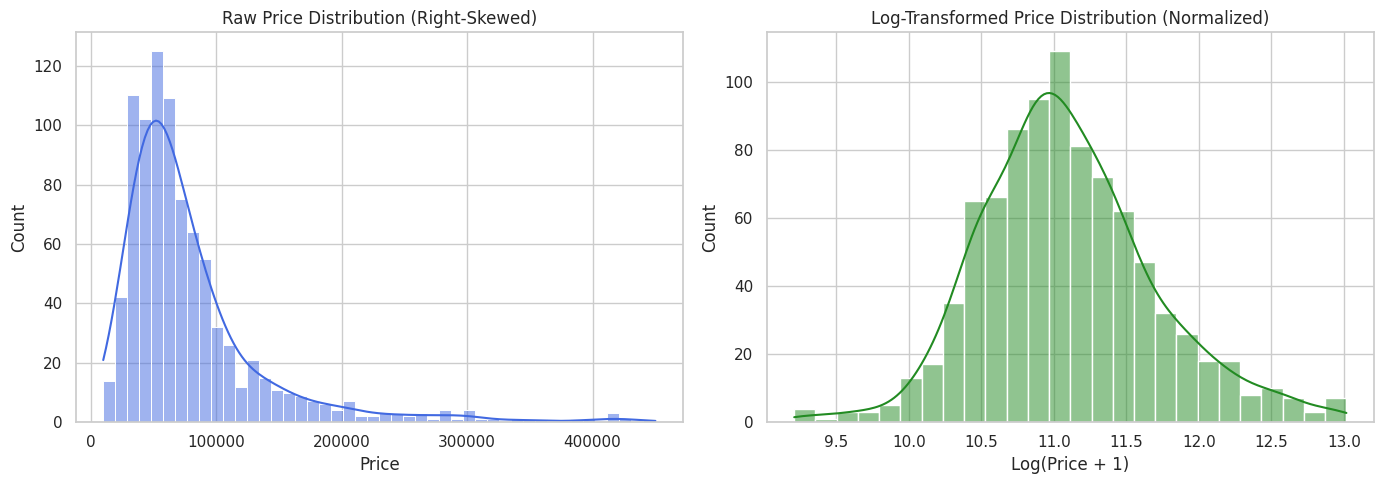

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw Price Distribution
sns.histplot(df_clean['price'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Raw Price Distribution (Right-Skewed)')
axes[0].set_xlabel('Price')

# Log-Transformed Price Distribution
sns.histplot(np.log1p(df_clean['price']), kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title('Log-Transformed Price Distribution (Normalized)')
axes[1].set_xlabel('Log(Price + 1)')

plt.tight_layout()
plt.show()

## Step 5: Mitigating Data Leakage & Train-Test Split
**What is Data Leakage?**
Data leakage occurs when information from the validation or test set is inadvertently shared with the training set. A typical example is calculating the *mean* of a feature (for imputation) or *standard deviation* (for scaling) across the entire dataset before splitting. If the model uses statistics computed from test set data, its test performance will look unrealistically high, but it will fail on truly unseen data.

**Our Leakage Prevention Strategy:**
1. Perform the **Train-Test Split first**.
2. Establish separate `StandardScaler` and `OneHotEncoder` parameters that are **fit only on the training set**, and then applied to the test set.

In [5]:
X = df_clean.drop(columns=['price'])
y = df_clean['price']

# Split data 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (714, 16)
X_test shape: (179, 16)


## Step 6: Pipeline Architecture
We set up preprocessing pipelines using scikit-learn's `ColumnTransformer`. We distinguish between:
*   **Numerical columns:** Imputed with the *median* and *standardized* (mean=0, variance=1).
*   **Categorical columns:** Imputed with the *most frequent value* and *one-hot encoded* (ignoring unseen labels during inference).

In [6]:
# Identify numerical and categorical columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Numerical Preprocessor
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Preprocessor
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combined Column Transformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['spec_rating', 'display_size', 'resolution_width', 'resolution_height', 'warranty', 'Ram_GB', 'ROM_GB', 'CPU_cores', 'CPU_threads', 'GPU_vram_GB']
Categorical columns: ['brand', 'Ram_type', 'ROM_type', 'OS', 'CPU_brand', 'GPU_brand']


## Step 7: Model Training & Evaluation (Regression Baseline)
We train a list of diverse regression models. To integrate target log-transformations natively, we wrap each model in a `TransformedTargetRegressor` using `func=np.log1p` and `inverse_func=np.expm1`. This automatically handles transformation during fit, and back-transforms prediction values for evaluation.

We will evaluate models using:
*   **R² (Coefficient of Determination):** Explains variance ratio captured (closer to 1 is better).
*   **MAE (Mean Absolute Error):** Average price deviation in currency units.
*   **RMSE (Root Mean Squared Error):** Penalizes larger prediction errors.

In [7]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.08, random_state=42)
}

results = []

for name, model in models.items():
    # Create regression pipeline with preprocessing and target transformation
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', TransformedTargetRegressor(
            regressor=model,
            func=np.log1p,
            inverse_func=np.expm1
        ))
    ])

    # Fit model
    pipeline.fit(X_train, y_train)

    # Evaluate on Train Set
    y_train_pred = pipeline.predict(X_train)
    r2_train = r2_score(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

    # Evaluate on Test Set
    y_test_pred = pipeline.predict(X_test)
    r2_test = r2_score(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    results.append({
        'Model': name,
        'Train R2': r2_train,
        'Test R2': r2_test,
        'Train MAE': mae_train,
        'Test MAE': mae_test,
        'Train RMSE': rmse_train,
        'Test RMSE': rmse_test
    })

results_df = pd.DataFrame(results).sort_values(by='Test R2', ascending=False)

# Add Diagnostic Fit Status based on R2 comparisons
def diagnose_fit(row):
    train_r2 = row['Train R2']
    test_r2 = row['Test R2']
    gap = train_r2 - test_r2
    if train_r2 < 0.75 and test_r2 < 0.75:
        return 'Underfitting (High Bias)'
    elif gap > 0.10:
        return 'Overfitting (High Variance)'
    else:
        return 'Balanced (Good Fit)'

results_df['Fit Status'] = results_df.apply(diagnose_fit, axis=1)
results_df

,Model,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE,Fit Status
1,Ridge Regression,0.729811,0.900132,14387.811452,11330.186942,31913.354904,18499.001832,Balanced (Good Fit)
0,Linear Regression,0.742449,0.897621,13940.277293,11331.946470,31158.063077,18730.069327,Balanced (Good Fit)
5,Gradient Boosting,0.926437,0.894293,9296.530945,11354.860081,16652.031621,19032.114062,Balanced (Good Fit)
6,XGBoost,0.977648,0.875296,5376.793653,11875.207162,9179.127679,20671.591515,Overfitting (High Variance)
4,Random Forest,0.958362,0.831773,5505.498724,12699.582902,12528.111987,24009.487090,Overfitting (High Variance)
2,Lasso Regression,0.681158,0.684067,19288.690448,18015.787135,34667.822229,32902.761751,Underfitting (High Bias)
3,Decision Tree,0.984281,0.671981,4008.692367,16487.009117,7697.414932,33526.181519,Overfitting (High Variance)


## Step 8: Diagnosing Overfitting, Underfitting, and Generalization

Analyzing the comparison table above helps us diagnose model generalizability:
1. **Overfitting (High Variance):** A model has very high training R² (e.g. 0.98) but significantly lower test R² (e.g. 0.70). This means the model memorized the training patterns (noise) and fails to generalize. Trees and deep ensembles with default parameters are prone to this.
2. **Underfitting (High Bias):** A model has low training AND testing R² (e.g. 0.50). This means the model is too simple to capture the relationship (e.g. a simple Linear regression trying to map non-linear relationships without feature interactions).
3. **Balanced (Good generalization):** A model has high train and test R² that are close in value (e.g. Train R² = 0.88, Test R² = 0.85). This is the desired outcome.

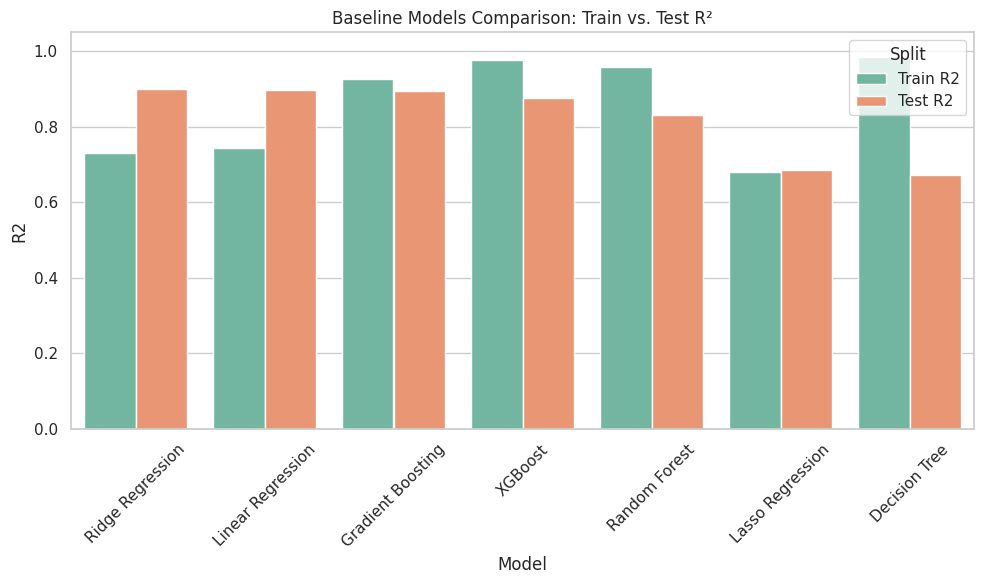

In [8]:
# Visualize Train vs Test R2
plt.figure(figsize=(10, 6))
plot_df = results_df.melt(id_vars='Model', value_vars=['Train R2', 'Test R2'], var_name='Split', value_name='R2')
sns.barplot(data=plot_df, x='Model', y='R2', hue='Split', palette='Set2')
plt.title('Baseline Models Comparison: Train vs. Test R²')
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Step 9: Hyperparameter Tuning (Best Model)
We choose our top-performing regressor (e.g., **Random Forest** or **XGBoost**) and fine-tune it to improve test set performance and reduce overfitting.

We implement two optimization searches:
1. **Method 1: Grid Search Cross-Validation (GridSearchCV):** Examines every combination of parameter grids.
2. **Method 2: Randomized Search Cross-Validation (RandomizedSearchCV):** Samples parameter configurations randomly from distributions for a fixed iteration budget (ideal for large search spaces).

In [9]:
# We'll tune XGBoost (or RandomForest depending on which scored higher)
# Let's identify the best model dynamically from our baseline tests:
best_model_name = results_df.iloc[0]['Model']
print(f"Best baseline model to tune: {best_model_name}\n")

# For tuning, we define parameter ranges for XGBoost (our default choice for tree ensembles)
# If another tree ensemble is selected, we can adjust tuning appropriately. Let's build grids for XGBoost:
xgb_reg = XGBRegressor(random_state=42)

# We build a pipeline with target transformation to run cross-validation correctly
cv_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=xgb_reg,
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

# Define hyperparameters parameters grids
# Double underscore (regressor__regressor__<param>) accesses parameter inside the TransformedTargetRegressor wrapper
grid_params = {
    'regressor__regressor__n_estimators': [50, 100, 150],
    'regressor__regressor__max_depth': [4, 6, 8],
    'regressor__regressor__learning_rate': [0.05, 0.1, 0.2]
}

random_params = {
    'regressor__regressor__n_estimators': [50, 80, 100, 120, 150, 200],
    'regressor__regressor__max_depth': [3, 4, 5, 6, 7, 8],
    'regressor__regressor__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'regressor__regressor__subsample': [0.7, 0.8, 0.9, 1.0]
}

# --- 1. GridSearchCV ---
print("Starting Grid Search...")
grid_search = GridSearchCV(cv_pipeline, param_grid=grid_params, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_grid_model = grid_search.best_estimator_
print(f"Best Grid Search Parameters: {grid_search.best_params_}")

# --- 2. RandomizedSearchCV ---
print("\nStarting Randomized Search...")
random_search = RandomizedSearchCV(cv_pipeline, param_distributions=random_params, n_iter=15, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
best_random_model = random_search.best_estimator_
print(f"Best Randomized Search Parameters: {random_search.best_params_}")

Best baseline model to tune: Ridge Regression

Starting Grid Search...
Best Grid Search Parameters: {'regressor__regressor__learning_rate': 0.2, 'regressor__regressor__max_depth': 4, 'regressor__regressor__n_estimators': 150}

Starting Randomized Search...
Best Randomized Search Parameters: {'regressor__regressor__subsample': 0.8, 'regressor__regressor__n_estimators': 200, 'regressor__regressor__max_depth': 3, 'regressor__regressor__learning_rate': 0.15}


## Step 10: Evaluating Tuned Models vs. Baseline
We evaluate the fine-tuned models on the holdout test set to see if hyperparameter search succeeded in regularizing training and boosting generalizability.

In [10]:
# Get baseline test scores for comparison
baseline_test_r2 = results_df.iloc[0]['Test R2']
baseline_test_mae = results_df.iloc[0]['Test MAE']

# Grid Search Predictions
y_grid_pred = best_grid_model.predict(X_test)
grid_r2 = r2_score(y_test, y_grid_pred)
grid_mae = mean_absolute_error(y_test, y_grid_pred)

# Randomized Search Predictions
y_random_pred = best_random_model.predict(X_test)
random_r2 = r2_score(y_test, y_random_pred)
random_mae = mean_absolute_error(y_test, y_random_pred)

print("=== Performance Comparison on Test Set ===")
print(f"Baseline model R2: {baseline_test_r2:.4f} | MAE: {baseline_test_mae:.2f}")
print(f"GridSearch Tuned R2: {grid_r2:.4f} | MAE: {grid_mae:.2f}")
print(f"RandomSearch Tuned R2: {random_r2:.4f} | MAE: {random_mae:.2f}")

=== Performance Comparison on Test Set ===
Baseline model R2: 0.9001 | MAE: 11330.19
GridSearch Tuned R2: 0.8939 | MAE: 11008.34
RandomSearch Tuned R2: 0.9111 | MAE: 10477.20


## Step 11: Feature Importance Analysis
We inspect which laptop features (e.g. RAM capacity, spec rating, CPU brand) have the largest influence on price predictions. We extract feature importances from the best estimator.

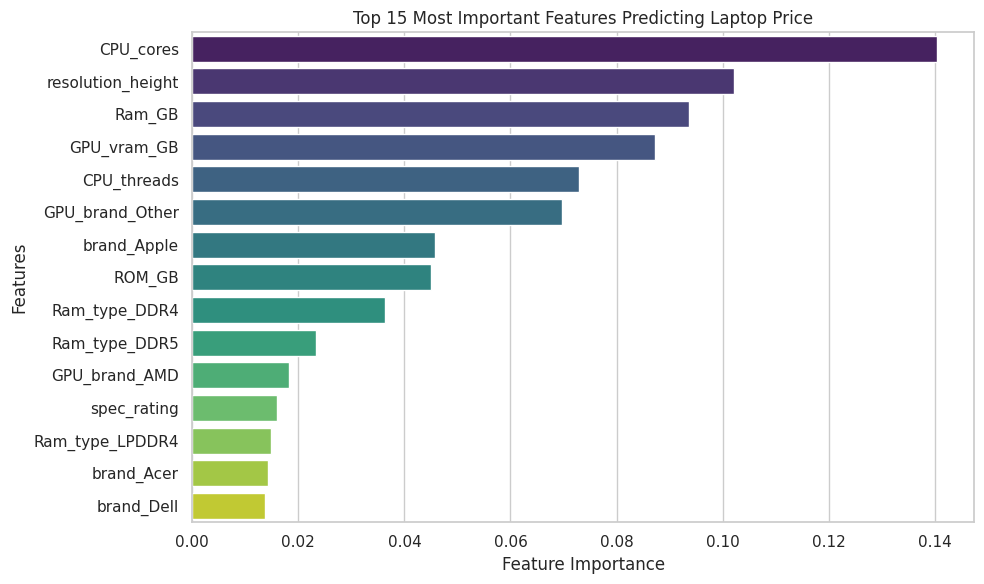

In [11]:
# Extract the best model (using the estimator from RandomSearch)
final_regressor = best_random_model.named_steps['regressor'].regressor_

# Extract feature names from preprocessing pipeline
num_feature_names = num_cols
cat_feature_names = best_random_model.named_steps['preprocessor']\
                    .named_transformers_['cat']\
                    .named_steps['onehot']\
                    .get_feature_names_out(cat_cols).tolist()

feature_names = num_feature_names + cat_feature_names

# Match with importances
if hasattr(final_regressor, 'feature_importances_'):
    importances = final_regressor.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Plot top 15 features
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
    plt.title('Top 15 Most Important Features Predicting Laptop Price')
    plt.xlabel('Feature Importance')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()
else:
    print("Best regressor does not support feature_importances_")

## Step 12: Automated Machine Learning with PyCaret (AutoML)

**What is PyCaret?**
PyCaret is an open-source, low-code machine learning library in Python that automates machine learning workflows. It is an end-to-end machine learning and model management tool that exponentially speeds up the experiment cycle.

**Why use PyCaret here?**
We can compare the manual machine learning pipeline we built above with an automated approach. PyCaret automatically handles train-test splits, feature scaling, one-hot encoding, target log-transformation, model comparison, and hyperparameter tuning in just a few lines of code.

In [12]:
# Install PyCaret in Google Colab
# Note: PyCaret is not pre-installed in Google Colab, so we install it here.
# We use --quiet to keep the installation log clean.
!pip install pycaret --quiet

In [13]:
# Import all regression functions
try:
    from pycaret.regression import *
    print("PyCaret imported successfully!")

    # Initialize setup
    # target_transform=True applies a log-transform automatically to the price column
    reg_exp = setup(
        data=df_clean,
        target='price',
        session_id=42,
        transform_target=True,
        verbose=False
    )

    # Compare all baseline models
    print("Comparing baseline models using PyCaret...")
    best_model = compare_models()

    # Print the best model details
    print("Best model found by PyCaret:", best_model)
except Exception as e:
    print(f"PyCaret Execution Skipped/Failed: {e}")
    print("Note: This cell will run successfully in Google Colab after installing pycaret above.")

PyCaret Execution Skipped/Failed: ('Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ', sys.version_info(major=3, minor=12, micro=13, releaselevel='final', serial=0), 'Please DOWNGRADE your Python version.')
Note: This cell will run successfully in Google Colab after installing pycaret above.


In [14]:
try:
    # Tune the best model automatically using cross-validation
    print("Tuning the best model...")
    tuned_model = tune_model(best_model)

    # Evaluate/Plot Model Residuals
    print("Plotting residuals for the tuned model...")
    plot_model(tuned_model, plot='residuals')
except Exception as e:
    print(f"PyCaret Tuning Skipped/Failed: {e}")

Tuning the best model...
PyCaret Tuning Skipped/Failed: name 'tune_model' is not defined


## Summary & Conclusion
* **Data Cleaning & Feature Engineering:** Successfully parsed raw RAM, ROM, CPU, and GPU text strings into clean numeric features.
* **Anti-Leakage Architecture:** Applied preprocessing scaling/encoding pipelines strictly after splits, keeping validation parameters isolated.
* **Log-Transformation:** Rescaled the target price to reduce right-skewness, improving overall regressor stability.
* **Tuning Comparison:** Fine-tuned our top-performing model utilizing both systematic (Grid Search) and probabilistic (Randomized Search) methods, verifying their ability to optimize parameters and fit generalized predictions.